In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Setting gaya visualisasi
sns.set_theme(style="whitegrid")

In [5]:
# Load dataset
df = pd.read_csv("dataset/dataset.csv")

# Menampilkan baris pertama dataset
display(df.head())

# Menampilkan informasi umum dataset (jumlah baris, kolom, dan tipe data)
print("\n=== Informasi Dataset ===")
df.info()

# Mengecek nilai yang hilang (Missing Values)
print("\n=== Jumlah Missing Values ===")
print(df.isnull().sum())

# Mengecek data yang duplikat
print("\n=== Jumlah Data Duplikat ===")
print("Duplikat:", df.duplicated().sum())

,tweet,category
0,Nest Protect mendapat penarikan kembali dan pe...,Technology
1,PS4 vs. Xbox One: 6 Bulan Kemudian,Technology
2,Pertemuan Gereja,Entertainment
3,"Facebook: Kami ""tidak punya rencana"" untuk men...",Technology
4,Kudeta di Thailand memicu pembatalan pemesanan...,Entertainment



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48704 entries, 0 to 48703
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tweet     48704 non-null  object
 1   category  48704 non-null  object
dtypes: object(2)
memory usage: 761.1+ KB

=== Jumlah Missing Values ===
tweet       0
category    0
dtype: int64

=== Jumlah Data Duplikat ===
Duplikat: 425


C:\Users\HP 840 G6\AppData\Local\Temp\ipykernel_23572\3244004861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='viridis')


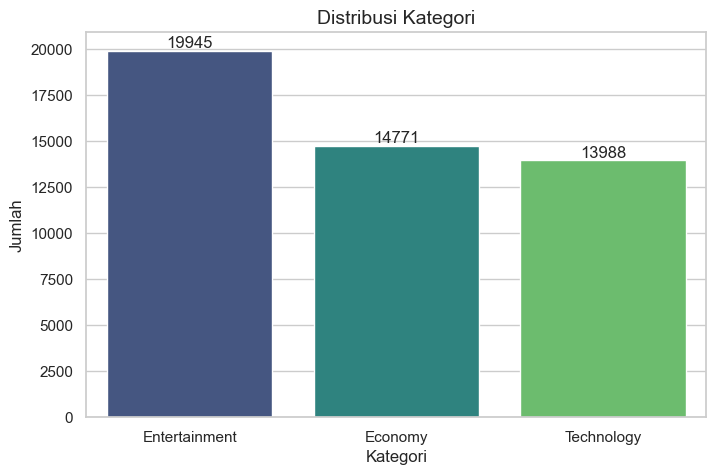

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='viridis')
plt.title('Distribusi Kategori', fontsize=14)
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 5), textcoords = 'offset points')
plt.show()

=== Statistik Panjang Teks ===


,char_count,word_count
count,48704.000000,48704.000000
mean,66.024659,9.427008
std,162.760044,11.985869
min,4.000000,1.000000
25%,52.000000,7.000000
50%,65.000000,9.000000
75%,78.000000,11.000000
max,25522.000000,1837.000000


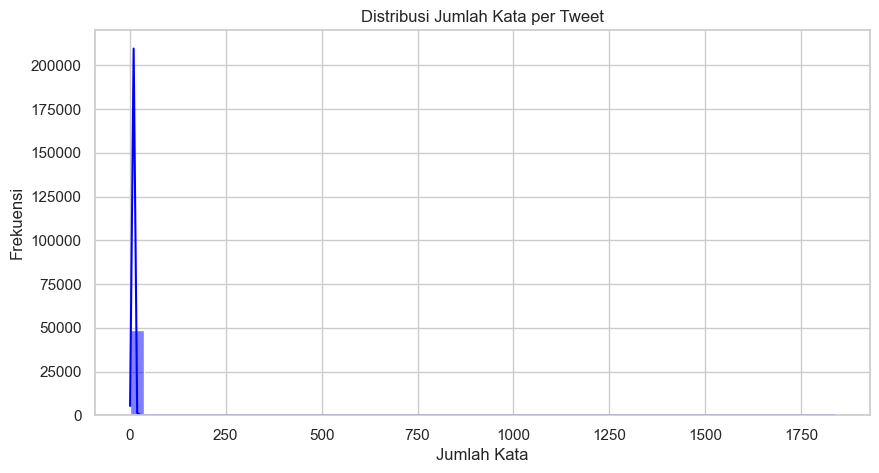

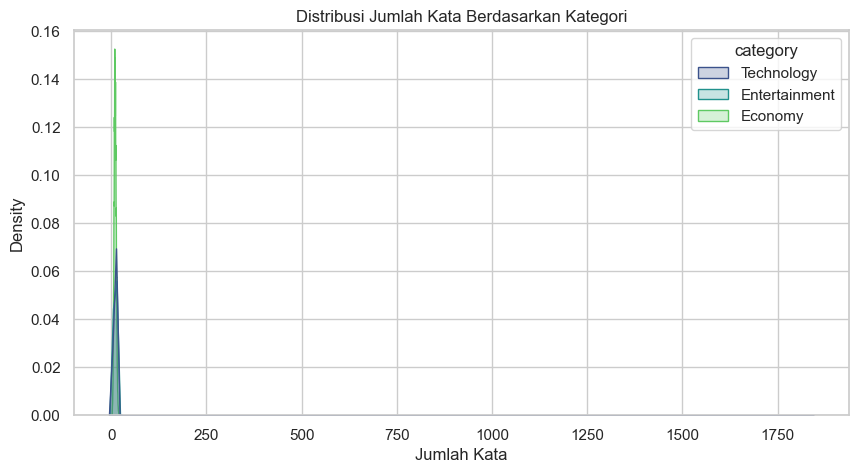

C:\Users\HP 840 G6\AppData\Local\Temp\ipykernel_23572\2733788026.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='word_count', palette='viridis')


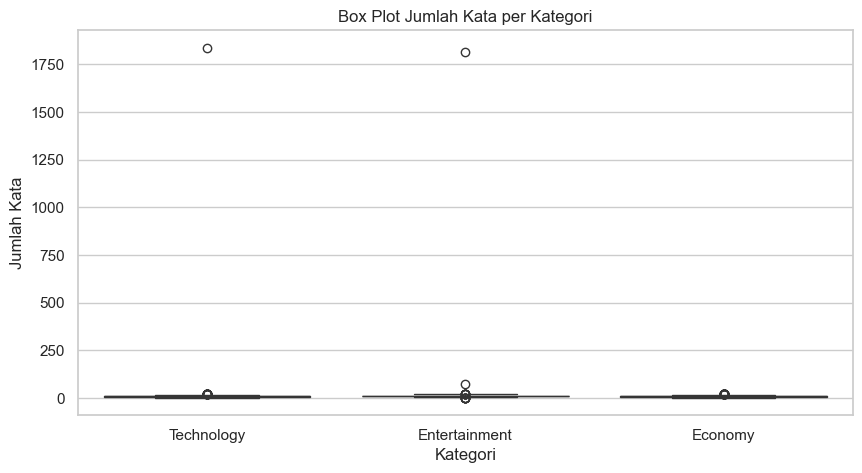

In [7]:
# Membuat kolom baru untuk panjang karakter dan jumlah kata
df['char_count'] = df['tweet'].apply(lambda x: len(str(x)))
df['word_count'] = df['tweet'].apply(lambda x: len(str(x).split()))

# Melihat statistik deskriptif dari panjang teks
print("=== Statistik Panjang Teks ===")
display(df[['char_count', 'word_count']].describe())

# Visualisasi Distribusi Jumlah Kata secara keseluruhan
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='blue')
plt.title('Distribusi Jumlah Kata per Tweet')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi Distribusi Jumlah Kata per Kategori (KDE Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='word_count', hue='category', fill=True, common_norm=False, palette='viridis')
plt.title('Distribusi Jumlah Kata Berdasarkan Kategori')
plt.xlabel('Jumlah Kata')
plt.ylabel('Density')
plt.show()

# Visualisasi Distribusi Jumlah Kata per Kategori (Box Plot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='category', y='word_count', palette='viridis')
plt.title('Box Plot Jumlah Kata per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Kata')
plt.show()

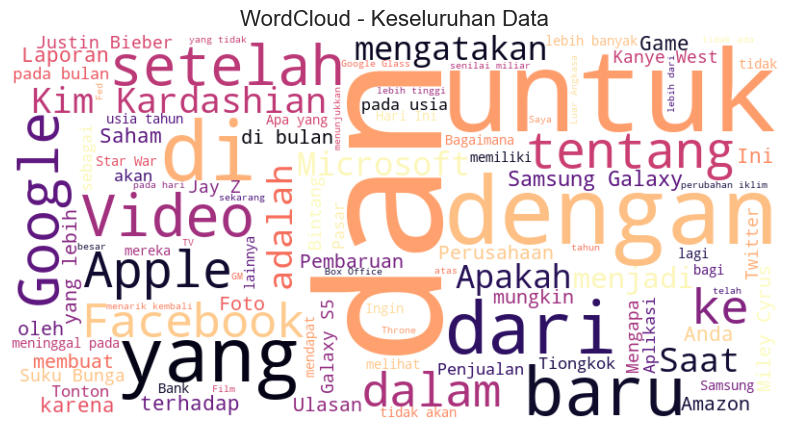

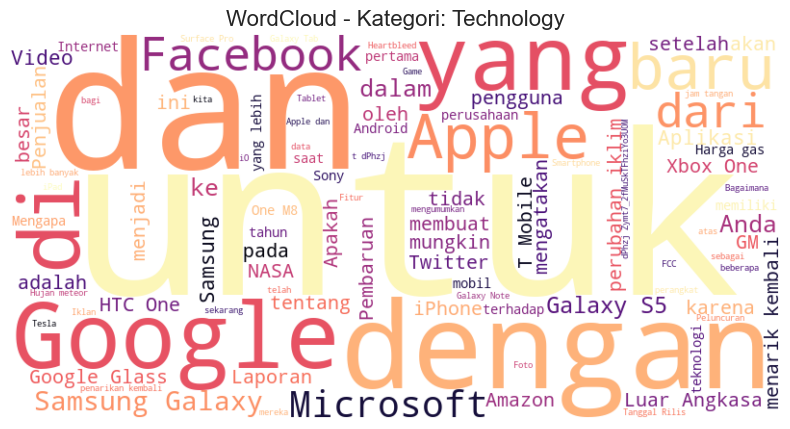

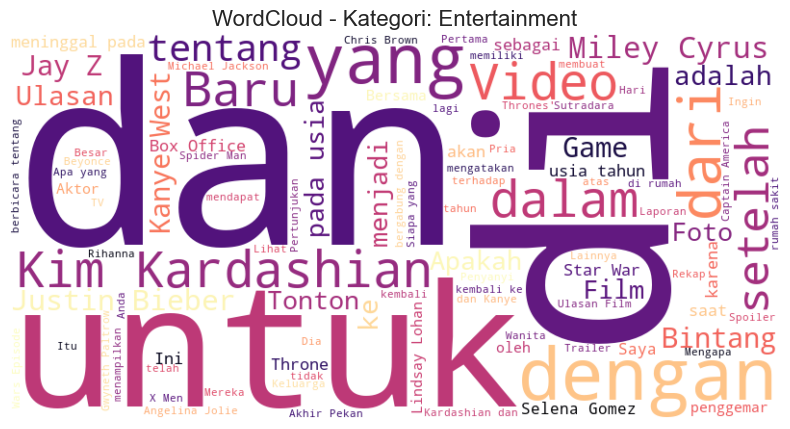

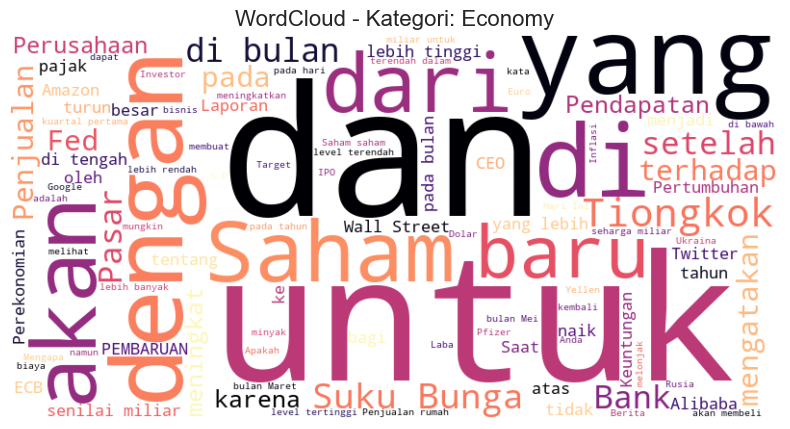

In [8]:
# Fungsi untuk membuat WordCloud
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          max_words=100, colormap='magma').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

# 1. WordCloud untuk seluruh dataset
all_text = " ".join(tweet for tweet in df['tweet'].astype(str))
plot_wordcloud(all_text, "WordCloud - Keseluruhan Data")

# 2. WordCloud untuk masing-masing kategori
categories = df['category'].unique()
for cat in categories:
    cat_text = " ".join(tweet for tweet in df[df['category'] == cat]['tweet'].astype(str))
    plot_wordcloud(cat_text, f"WordCloud - Kategori: {cat}")

C:\Users\HP 840 G6\AppData\Local\Temp\ipykernel_23572\557136069.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='mako')


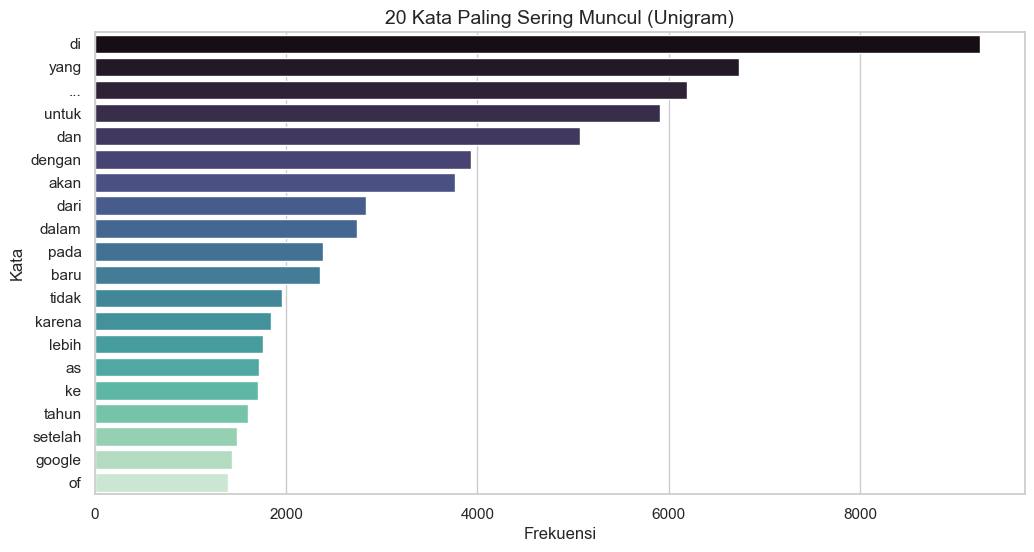

In [9]:
# Mengambil semua kata dan menghitung frekuensinya
all_words = " ".join(df['tweet'].astype(str)).lower().split()
word_counts = Counter(all_words)

# Mengambil 20 kata terbanyak
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)

# Visualisasi Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='mako')
plt.title('20 Kata Paling Sering Muncul (Unigram)', fontsize=14)
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

C:\Users\HP 840 G6\AppData\Local\Temp\ipykernel_23572\1716008219.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bi, x='Count', y='Bigram', palette='viridis')


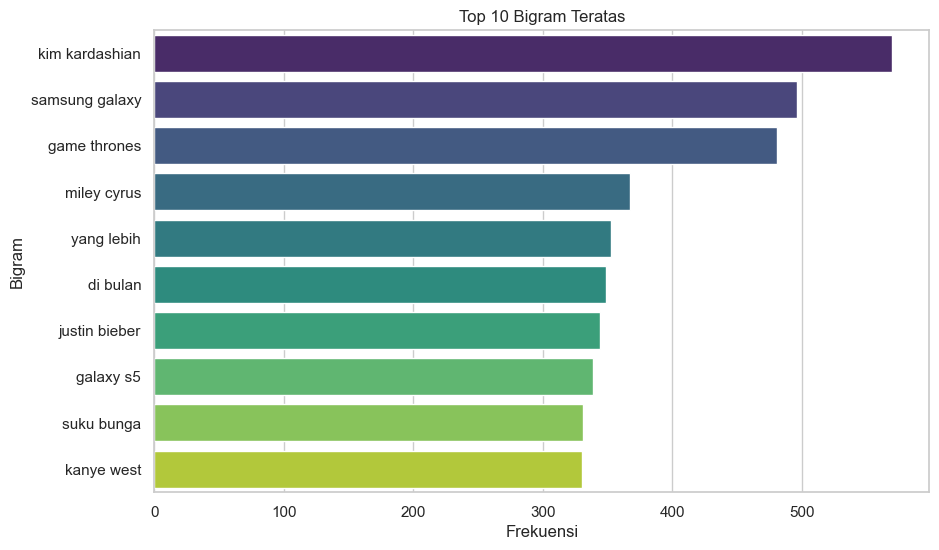

In [10]:
# 1. Inisialisasi CountVectorizer untuk Bigram
vectorizer_bi = CountVectorizer(ngram_range=(2, 2), stop_words='english') # Sesuaikan stop_words jika perlu
X_bi = vectorizer_bi.fit_transform(df['tweet'].astype(str))

# 2. Menghitung frekuensi bigram
bi_counts = X_bi.sum(axis=0)
bi_freq = [(word, bi_counts[0, idx]) for word, idx in vectorizer_bi.vocabulary_.items()]
bi_freq = sorted(bi_freq, key=lambda x: x[1], reverse=True)

# 3. Membuat DataFrame untuk 10 Bigram teratas
df_bi = pd.DataFrame(bi_freq[:10], columns=['Bigram', 'Count'])

# 4. Visualisasi Bigram teratas
plt.figure(figsize=(10, 6))
sns.barplot(data=df_bi, x='Count', y='Bigram', palette='viridis')
plt.title('Top 10 Bigram Teratas')
plt.xlabel('Frekuensi')
plt.ylabel('Bigram')
plt.show()

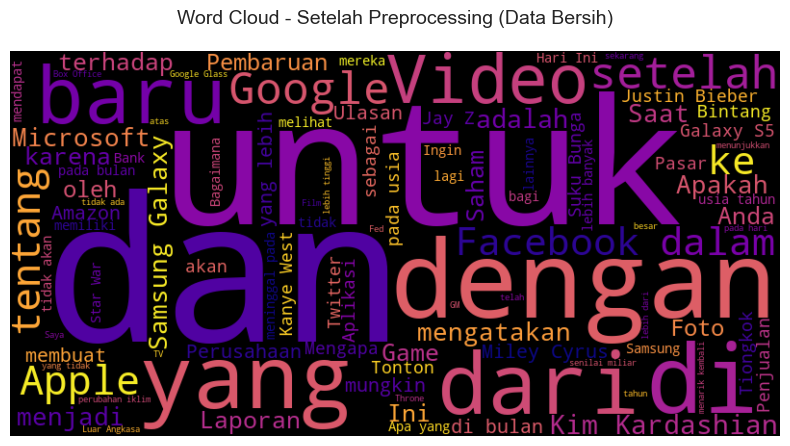

In [12]:
# Pastikan Anda menggunakan kolom teks yang sudah melewati proses stemming/stopword removal
# Contoh di bawah mengasumsikan kolomnya bernama 'tweet_clean' atau disesuaikan dengan data bersih Anda
clean_text = " ".join(df['tweet'].astype(str))

# Membuat Word Cloud data bersih
wordcloud_clean = WordCloud(
    width=800, 
    height=400, 
    background_color='black', # Diubah jadi hitam agar kontras perbedaannya terlihat
    colormap='plasma',
    max_words=100
).generate(clean_text)

# Menampilkan Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Setelah Preprocessing (Data Bersih)', fontsize=14, pad=20)
plt.show()